In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les graphiques en français
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Chargement des données
print("Chargement des données...")
df = pd.read_csv('assets/caract-2023.csv', sep=';', encoding='utf-8')
print(f"Données chargées : {len(df)} enregistrements")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPremières lignes :")
print(df.head())

Chargement des données...
Données chargées : 54822 enregistrements

Colonnes : ['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'adr', 'lat', 'long']

Premières lignes :
        Num_Acc  jour  mois    an   hrmn  lum dep    com  agg  int  atm  col  \
0  202300000001     7     5  2023  06:00    1  75  75101    2    4    2    7   
1  202300000002     7     5  2023  05:30    5  94  94080    2    1    3    6   
2  202300000003     7     5  2023  20:50    1  94  94022    2    3    2    1   
3  202300000004     6     5  2023  23:57    5  94  94078    2    1    3    5   
4  202300000005     7     5  2023  00:50    5  94  94068    2    2    3    3   

                         adr          lat        long  
0              RUE DE RIVOLI  48,86638600  2,32347100  
1            Avenue de Paris  48,84547782  2,42868146  
2  Avenue du Général Leclerc  48,76240000  2,40655000  
3               Rue de Paris  48,73248432  2,44687575  
4       56bis Avenue Raspai

In [7]:
# Conversion des colonnes de date au format approprié
df['date'] = pd.to_datetime(df['an'].astype(str) + '-' + 
                            df['mois'].astype(str).str.zfill(2) + '-' + 
                            df['jour'].astype(str).str.zfill(2), 
                            format='%Y-%m-%d', errors='coerce')

# Extraction des caractéristiques temporelles
df['jour_semaine'] = df['date'].dt.day_name()
df['jour_semaine_num'] = df['date'].dt.dayofweek  # 0=Lundi, 6=Dimanche
df['jour_mois'] = df['jour'].astype(int)
df['mois_annee'] = df['mois'].astype(int)

# Traduction des jours de la semaine en français
jours_fr = {
    'Monday': 'Lundi',
    'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi',
    'Thursday': 'Jeudi',
    'Friday': 'Vendredi',
    'Saturday': 'Samedi',
    'Sunday': 'Dimanche'
}
df['jour_semaine_fr'] = df['jour_semaine'].map(jours_fr)

# Traduction des mois en français
mois_fr = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}
df['mois_nom'] = df['mois_annee'].map(mois_fr)

# Parsing de l'heure
df['heure'] = pd.to_datetime(df['hrmn'], format='%H:%M', errors='coerce').dt.hour
df['minute'] = pd.to_datetime(df['hrmn'], format='%H:%M', errors='coerce').dt.minute

# Création de périodes de la journée
df['periode_journee'] = pd.cut(df['heure'], 
                               bins=[0, 6, 12, 18, 24], 
                               labels=['Nuit (0-6h)', 'Matin (6-12h)', 'Après-midi (12-18h)', 'Soirée (18-24h)'],
                               include_lowest=True)

print("Vérification des valeurs manquantes :")
print(df[['date', 'jour_semaine_fr', 'jour_mois', 'mois_annee', 'heure', 'periode_journee']].isnull().sum())
print(f"\nTotal des enregistrements : {len(df)}")
print(f"Enregistrements valides : {len(df.dropna(subset=['date', 'heure']))}")

Vérification des valeurs manquantes :
date               0
jour_semaine_fr    0
jour_mois          0
mois_annee         0
heure              0
periode_journee    0
dtype: int64

Total des enregistrements : 54822
Enregistrements valides : 54822


1. ANALYSE PAR JOUR DE LA SEMAINE

Fréquence par jour de la semaine :
------------------------------------------------------------
Lundi          :   7279 accidents (13.28%)
Mardi          :   8090 accidents (14.76%)
Mercredi       :   8117 accidents (14.81%)
Jeudi          :   8001 accidents (14.59%)
Vendredi       :   8873 accidents (16.19%)
Samedi         :   7761 accidents (14.16%)
Dimanche       :   6701 accidents (12.22%)

Total : 54822 accidents

Moyenne d'accidents par jour : 7831.71
Écart-type : 689.21
Minimum : 6701 (Dimanche)
Maximum : 8873 (Vendredi)
Médiane : 8001.00


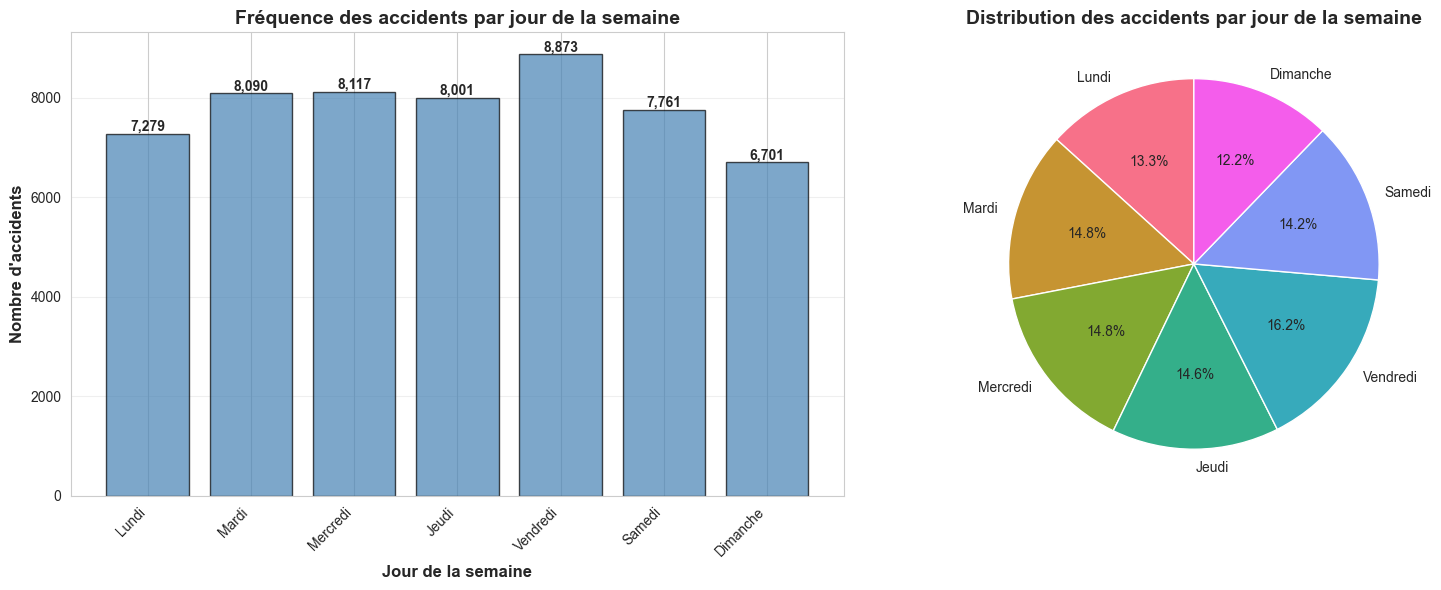

In [8]:
# ============================================================================
# 1. STATISTIQUES DESCRIPTIVES - JOURS DE LA SEMAINE
# ============================================================================
print("="*80)
print("1. ANALYSE PAR JOUR DE LA SEMAINE")
print("="*80)

# Ordre des jours (Lundi à Dimanche)
ordre_jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

# Fréquences
freq_jours = df['jour_semaine_fr'].value_counts()
freq_jours = freq_jours.reindex([j for j in ordre_jours if j in freq_jours.index])
freq_jours_pct = (freq_jours / len(df) * 100).round(2)

print("\nFréquence par jour de la semaine :")
print("-" * 60)
for jour in ordre_jours:
    if jour in freq_jours.index:
        count = freq_jours[jour]
        pct = freq_jours_pct[jour]
        print(f"{jour:15s}: {count:6d} accidents ({pct:5.2f}%)")

print(f"\nTotal : {freq_jours.sum()} accidents")
print(f"\nMoyenne d'accidents par jour : {freq_jours.mean():.2f}")
print(f"Écart-type : {freq_jours.std():.2f}")
print(f"Minimum : {freq_jours.min()} ({freq_jours.idxmin()})")
print(f"Maximum : {freq_jours.max()} ({freq_jours.idxmax()})")
print(f"Médiane : {freq_jours.median():.2f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique en barres
axes[0].bar(range(len(freq_jours)), freq_jours.values, 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(freq_jours)))
axes[0].set_xticklabels(freq_jours.index, rotation=45, ha='right')
axes[0].set_xlabel('Jour de la semaine', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[0].set_title('Fréquence des accidents par jour de la semaine', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Ajout des valeurs sur les barres
for i, v in enumerate(freq_jours.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Graphique en camembert
axes[1].pie(freq_jours.values, labels=freq_jours.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette("husl", len(freq_jours)))
axes[1].set_title('Distribution des accidents par jour de la semaine', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


2. ANALYSE PAR HEURE DE LA JOURNÉE

Fréquence par heure de la journée :
------------------------------------------------------------
Heure  0:00 -  0:59:   1012 accidents ( 1.85%)
Heure  1:00 -  1:59:    903 accidents ( 1.65%)
Heure  2:00 -  2:59:    752 accidents ( 1.37%)
Heure  3:00 -  3:59:    643 accidents ( 1.17%)
Heure  4:00 -  4:59:    644 accidents ( 1.17%)
Heure  5:00 -  5:59:    800 accidents ( 1.46%)
Heure  6:00 -  6:59:   1241 accidents ( 2.26%)
Heure  7:00 -  7:59:   2594 accidents ( 4.73%)
Heure  8:00 -  8:59:   3396 accidents ( 6.19%)
Heure  9:00 -  9:59:   2764 accidents ( 5.04%)
Heure 10:00 - 10:59:   2444 accidents ( 4.46%)
Heure 11:00 - 11:59:   2662 accidents ( 4.86%)
Heure 12:00 - 12:59:   2903 accidents ( 5.30%)
Heure 13:00 - 13:59:   2657 accidents ( 4.85%)
Heure 14:00 - 14:59:   2847 accidents ( 5.19%)
Heure 15:00 - 15:59:   3248 accidents ( 5.92%)
Heure 16:00 - 16:59:   3851 accidents ( 7.02%)
Heure 17:00 - 17:59:   4470 accidents ( 8.15%)
Heure 18:00 - 18:59:

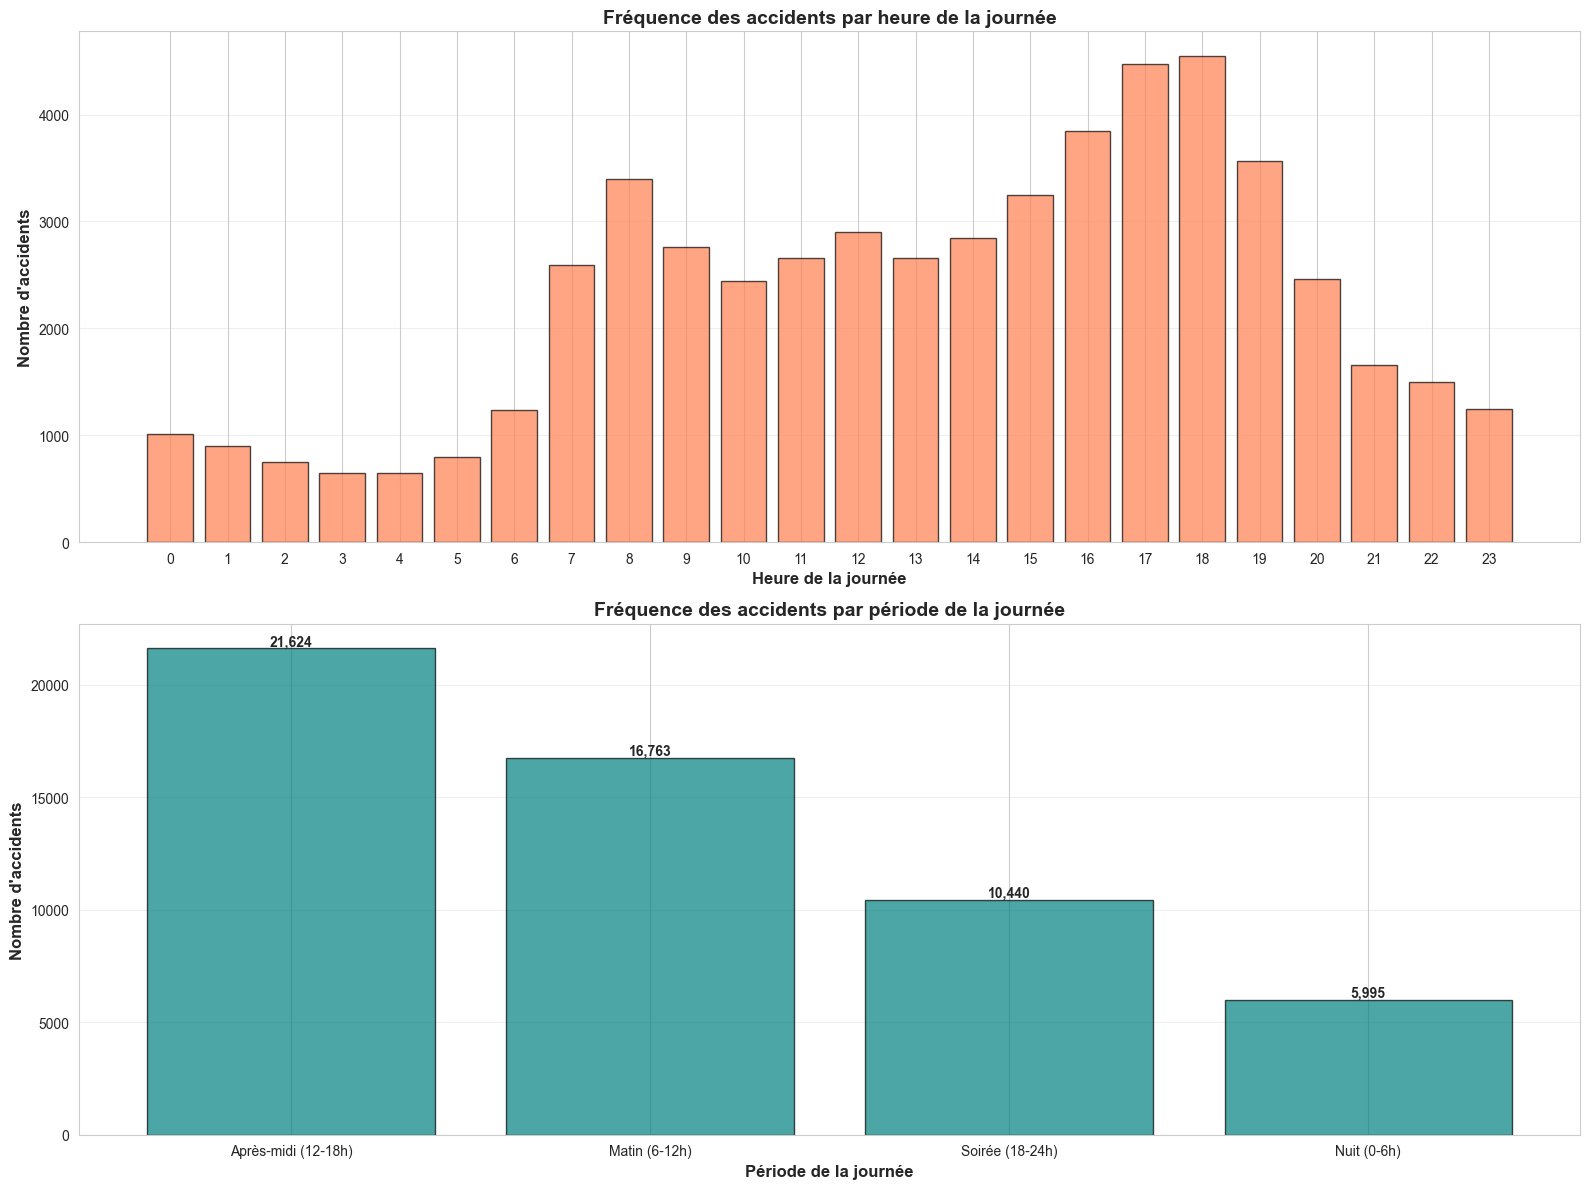

In [9]:
# ============================================================================
# 2. STATISTIQUES DESCRIPTIVES - HEURE DE LA JOURNÉE
# ============================================================================
print("\n" + "="*80)
print("2. ANALYSE PAR HEURE DE LA JOURNÉE")
print("="*80)

# Par heure
freq_heures = df['heure'].value_counts().sort_index()
freq_heures_pct = (df['heure'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nFréquence par heure de la journée :")
print("-" * 60)
for heure in sorted(freq_heures.index):
    count = freq_heures[heure]
    pct = freq_heures_pct[heure]
    print(f"Heure {heure:2d}:00 - {heure:2d}:59: {count:6d} accidents ({pct:5.2f}%)")

print(f"\nHeure de pointe : {freq_heures.idxmax()}:00 ({freq_heures.max()} accidents)")
print(f"Heure la plus basse : {freq_heures.idxmin()}:00 ({freq_heures.min()} accidents)")
print(f"Moyenne d'accidents par heure : {freq_heures.mean():.2f}")
print(f"Écart-type : {freq_heures.std():.2f}")
print(f"Médiane : {freq_heures.median():.2f}")

# Par période de la journée
freq_periodes = df['periode_journee'].value_counts()
freq_periodes_pct = (df['periode_journee'].value_counts(normalize=True) * 100).round(2)

print("\nFréquence par période de la journée :")
print("-" * 60)
for periode, count in freq_periodes.items():
    pct = freq_periodes_pct[periode]
    print(f"{periode:25s}: {count:6d} accidents ({pct:5.2f}%)")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Distribution horaire
axes[0].bar(freq_heures.index, freq_heures.values, color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Heure de la journée', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[0].set_title('Fréquence des accidents par heure de la journée', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis='y', alpha=0.3)

# Distribution par période
axes[1].bar(range(len(freq_periodes)), freq_periodes.values, 
            color='teal', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(freq_periodes)))
axes[1].set_xticklabels(freq_periodes.index, rotation=0)
axes[1].set_xlabel('Période de la journée', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[1].set_title('Fréquence des accidents par période de la journée', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Ajout des valeurs
for i, v in enumerate(freq_periodes.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


3. ANALYSE PAR JOUR DU MOIS

Fréquence par jour du mois :
------------------------------------------------------------
Jour  1:   1765 accidents ( 3.22%)
Jour  2:   1717 accidents ( 3.13%)
Jour  3:   1845 accidents ( 3.37%)
Jour  4:   1930 accidents ( 3.52%)
Jour  5:   1795 accidents ( 3.27%)
Jour  6:   1995 accidents ( 3.64%)
Jour  7:   2013 accidents ( 3.67%)
Jour  8:   1927 accidents ( 3.52%)
Jour  9:   1931 accidents ( 3.52%)
Jour 10:   1896 accidents ( 3.46%)
Jour 11:   1812 accidents ( 3.31%)
Jour 12:   1769 accidents ( 3.23%)
Jour 13:   1913 accidents ( 3.49%)
Jour 14:   1871 accidents ( 3.41%)
Jour 15:   1775 accidents ( 3.24%)
Jour 16:   1889 accidents ( 3.45%)
Jour 17:   1783 accidents ( 3.25%)
Jour 18:   1783 accidents ( 3.25%)
Jour 19:   1783 accidents ( 3.25%)
Jour 20:   1847 accidents ( 3.37%)
Jour 21:   1825 accidents ( 3.33%)
Jour 22:   1717 accidents ( 3.13%)
Jour 23:   1723 accidents ( 3.14%)
Jour 24:   1830 accidents ( 3.34%)
Jour 25:   1627 accidents ( 2.97%)
Jour 

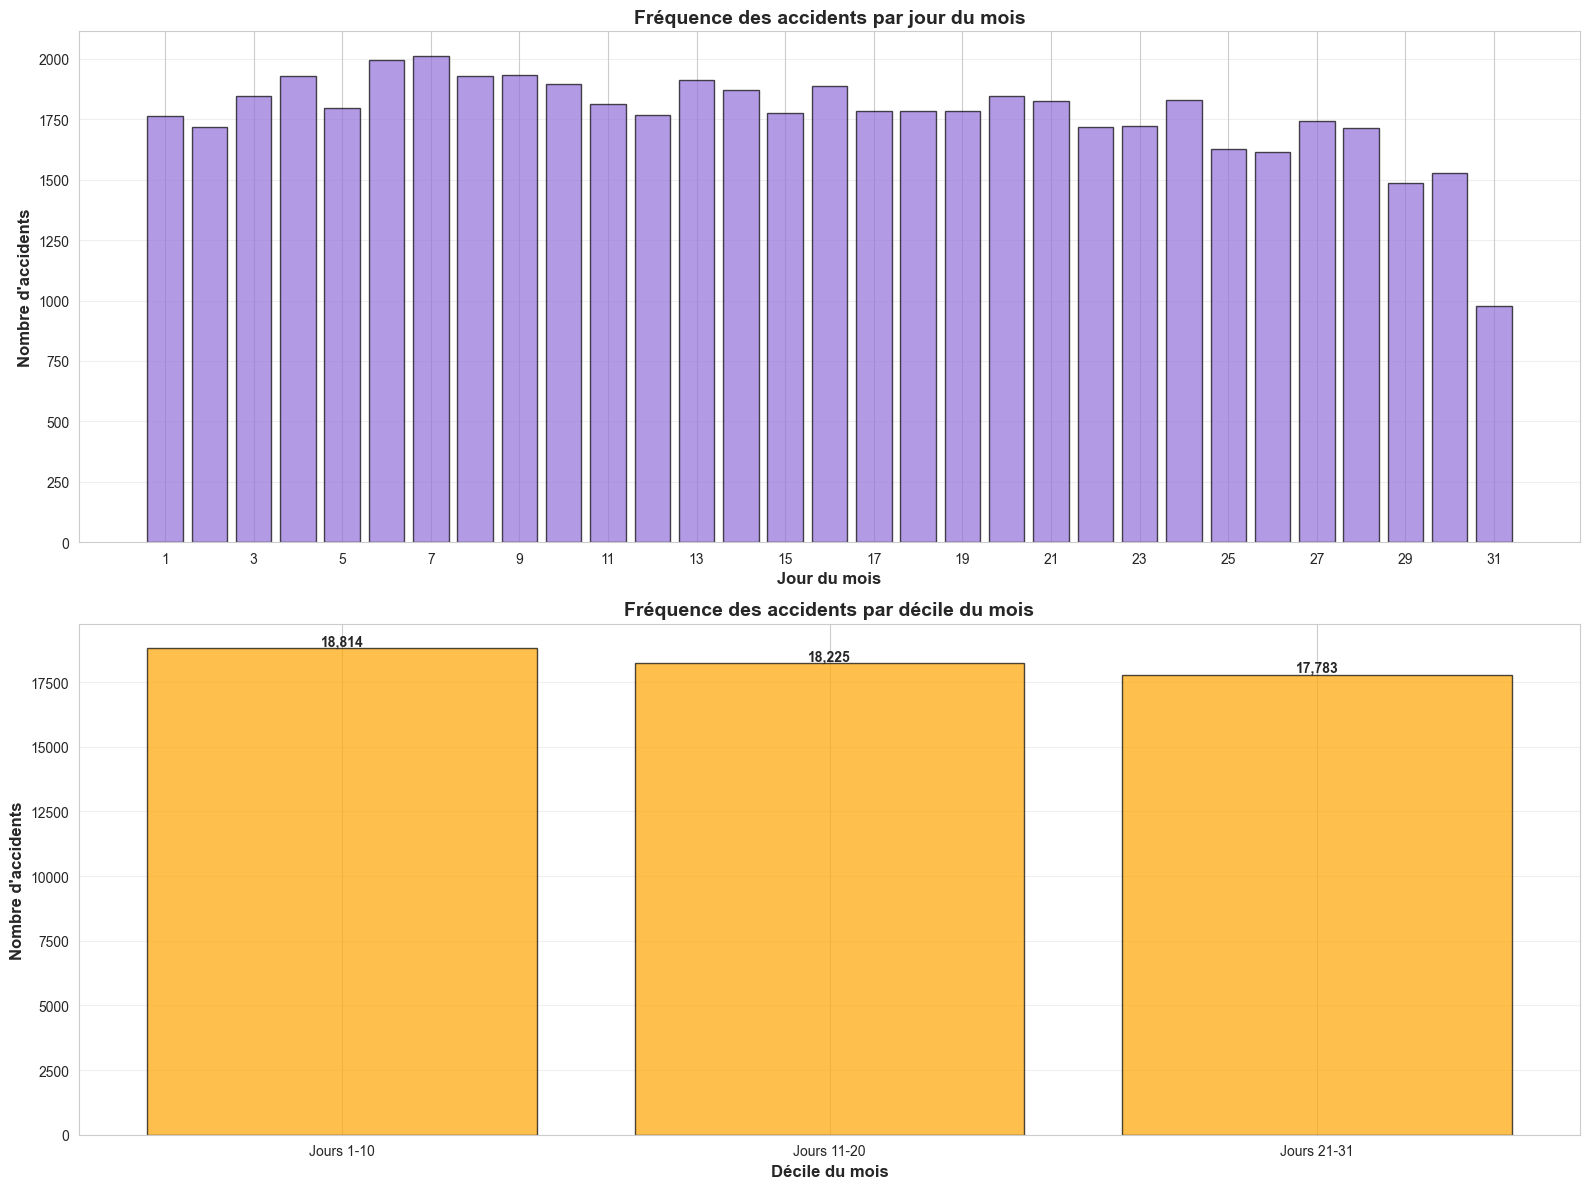

In [10]:
# ============================================================================
# 3. STATISTIQUES DESCRIPTIVES - JOUR DU MOIS
# ============================================================================
print("\n" + "="*80)
print("3. ANALYSE PAR JOUR DU MOIS")
print("="*80)

# Fréquences par jour du mois
freq_jour_mois = df['jour_mois'].value_counts().sort_index()
freq_jour_mois_pct = (df['jour_mois'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nFréquence par jour du mois :")
print("-" * 60)
for jour in sorted(freq_jour_mois.index):
    count = freq_jour_mois[jour]
    pct = freq_jour_mois_pct[jour]
    print(f"Jour {jour:2d}: {count:6d} accidents ({pct:5.2f}%)")

print(f"\nTotal : {freq_jour_mois.sum()} accidents")
print(f"\nMoyenne d'accidents par jour du mois : {freq_jour_mois.mean():.2f}")
print(f"Écart-type : {freq_jour_mois.std():.2f}")
print(f"Minimum : {freq_jour_mois.min()} (jour {freq_jour_mois.idxmin()})")
print(f"Maximum : {freq_jour_mois.max()} (jour {freq_jour_mois.idxmax()})")
print(f"Médiane : {freq_jour_mois.median():.2f}")

# Regroupement par déciles du mois
df['decile_mois'] = pd.cut(df['jour_mois'], 
                           bins=[0, 10, 20, 31], 
                           labels=['1-10', '11-20', '21-31'],
                           include_lowest=True)
freq_deciles = df['decile_mois'].value_counts().sort_index()
freq_deciles_pct = (df['decile_mois'].value_counts(normalize=True).sort_index() * 100).round(2)

print("\nFréquence par décile du mois :")
print("-" * 60)
for decile, count in freq_deciles.items():
    pct = freq_deciles_pct[decile]
    print(f"Jours {decile:8s}: {count:6d} accidents ({pct:5.2f}%)")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Distribution par jour du mois
axes[0].bar(freq_jour_mois.index, freq_jour_mois.values, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Jour du mois', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[0].set_title('Fréquence des accidents par jour du mois', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 32, 2))
axes[0].grid(axis='y', alpha=0.3)

# Distribution par décile
axes[1].bar(range(len(freq_deciles)), freq_deciles.values, 
            color='orange', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(freq_deciles)))
axes[1].set_xticklabels([f"Jours {d}" for d in freq_deciles.index])
axes[1].set_xlabel('Décile du mois', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[1].set_title('Fréquence des accidents par décile du mois', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Ajout des valeurs
for i, v in enumerate(freq_deciles.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


4. ANALYSE PAR MOIS DE L'ANNÉE

Fréquence par mois de l'année :
------------------------------------------------------------
Janvier        :   4053 accidents ( 7.39%)
Février        :   3682 accidents ( 6.72%)
Mars           :   3998 accidents ( 7.29%)
Avril          :   4162 accidents ( 7.59%)
Mai            :   4767 accidents ( 8.70%)
Juin           :   5452 accidents ( 9.94%)
Juillet        :   4754 accidents ( 8.67%)
Août           :   4121 accidents ( 7.52%)
Septembre      :   5161 accidents ( 9.41%)
Octobre        :   5389 accidents ( 9.83%)
Novembre       :   4833 accidents ( 8.82%)
Décembre       :   4450 accidents ( 8.12%)

Total : 54822 accidents

Moyenne d'accidents par mois : 4568.50
Écart-type : 580.38
Minimum : 3682 (Février)
Maximum : 5452 (Juin)
Médiane : 4602.00

Fréquence par saison :
------------------------------------------------------------
Printemps      :  12927 accidents (23.58%)
Été            :  14327 accidents (26.13%)
Automne        :  15383 accidents (28

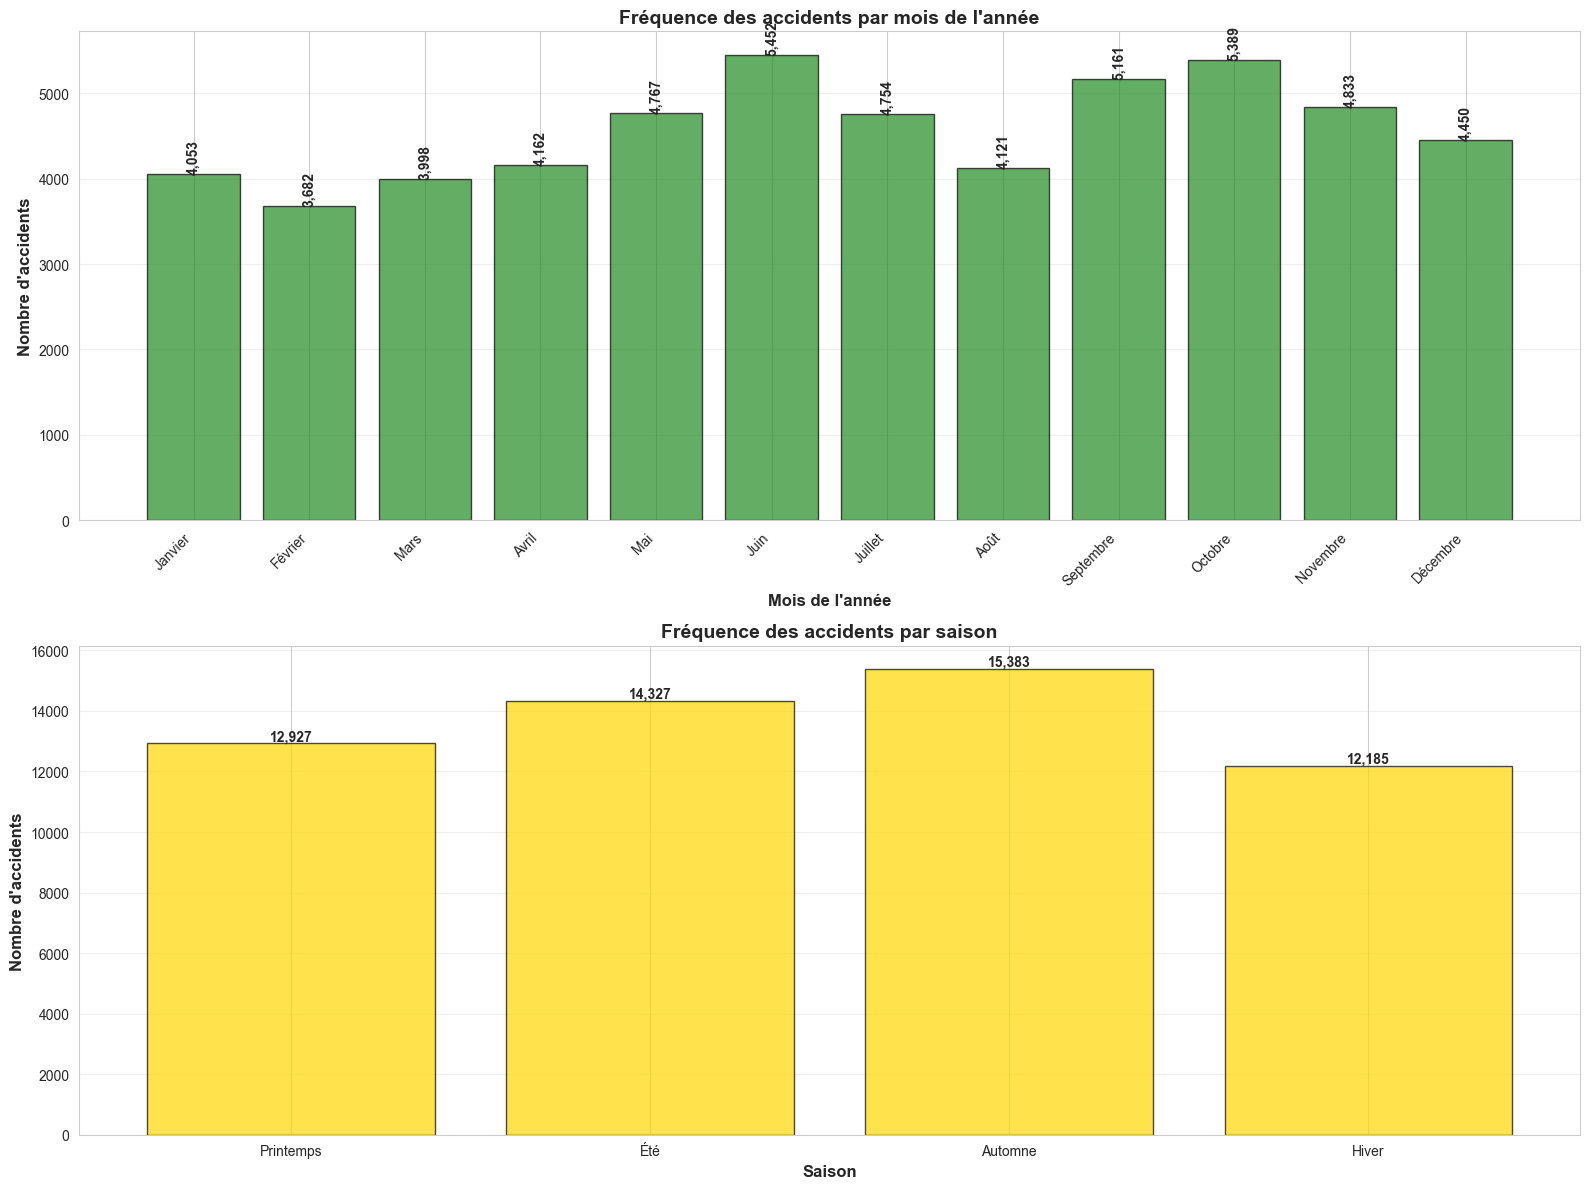

In [11]:
# ============================================================================
# 4. STATISTIQUES DESCRIPTIVES - MOIS DE L'ANNÉE
# ============================================================================
print("\n" + "="*80)
print("4. ANALYSE PAR MOIS DE L'ANNÉE")
print("="*80)

# Ordre des mois
ordre_mois = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
              'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

# Fréquences
freq_mois = df['mois_nom'].value_counts()
freq_mois = freq_mois.reindex([m for m in ordre_mois if m in freq_mois.index])
freq_mois_pct = (freq_mois / len(df) * 100).round(2)

print("\nFréquence par mois de l'année :")
print("-" * 60)
for mois in ordre_mois:
    if mois in freq_mois.index:
        count = freq_mois[mois]
        pct = freq_mois_pct[mois]
        print(f"{mois:15s}: {count:6d} accidents ({pct:5.2f}%)")

print(f"\nTotal : {freq_mois.sum()} accidents")
print(f"\nMoyenne d'accidents par mois : {freq_mois.mean():.2f}")
print(f"Écart-type : {freq_mois.std():.2f}")
print(f"Minimum : {freq_mois.min()} ({freq_mois.idxmin()})")
print(f"Maximum : {freq_mois.max()} ({freq_mois.idxmax()})")
print(f"Médiane : {freq_mois.median():.2f}")

# Regroupement par saison
saisons = {
    'Janvier': 'Hiver', 'Février': 'Hiver', 'Mars': 'Printemps',
    'Avril': 'Printemps', 'Mai': 'Printemps', 'Juin': 'Été',
    'Juillet': 'Été', 'Août': 'Été', 'Septembre': 'Automne',
    'Octobre': 'Automne', 'Novembre': 'Automne', 'Décembre': 'Hiver'
}
df['saison'] = df['mois_nom'].map(saisons)
freq_saisons = df['saison'].value_counts()
freq_saisons_pct = (df['saison'].value_counts(normalize=True) * 100).round(2)

print("\nFréquence par saison :")
print("-" * 60)
ordre_saisons = ['Printemps', 'Été', 'Automne', 'Hiver']
for saison in ordre_saisons:
    if saison in freq_saisons.index:
        count = freq_saisons[saison]
        pct = freq_saisons_pct[saison]
        print(f"{saison:15s}: {count:6d} accidents ({pct:5.2f}%)")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Distribution par mois
axes[0].bar(range(len(freq_mois)), freq_mois.values, 
            color='forestgreen', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(freq_mois)))
axes[0].set_xticklabels(freq_mois.index, rotation=45, ha='right')
axes[0].set_xlabel('Mois de l\'année', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[0].set_title('Fréquence des accidents par mois de l\'année', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Ajout des valeurs
for i, v in enumerate(freq_mois.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold', rotation=90)

# Distribution par saison
freq_saisons_ordre = freq_saisons.reindex([s for s in ordre_saisons if s in freq_saisons.index])
axes[1].bar(range(len(freq_saisons_ordre)), freq_saisons_ordre.values, 
            color='gold', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(freq_saisons_ordre)))
axes[1].set_xticklabels(freq_saisons_ordre.index)
axes[1].set_xlabel('Saison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nombre d\'accidents', fontsize=12, fontweight='bold')
axes[1].set_title('Fréquence des accidents par saison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Ajout des valeurs
for i, v in enumerate(freq_saisons_ordre.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()